# Preprocessing — Autoencoder Anomaly Detection

Notebook ini membangun dataset training dengan mengombinasikan fitur dari tiga sumber data.

**Fitur output per transaksi:**
| Fitur | Sumber | Keterangan |
|---|---|---|
| `persona_encoded` | `data_nasabah` | Tightwad=0 · Unconflicted=1 · Spendthrift=2 |
| `kategori_encoded` | `data_transaksi` | Belanja=0 · F&B=1 · Groceries=2 · Hiburan=3 · Investasi=4 · Kesehatan=5 · NLP=6 · Produktivitas=7 · Tagihan=8 · Transportasi=9 |
| `savings_rate` | `features_nasabah` | Rasio tabungan bulan ini |
| `night_owl_spending` | `features_nasabah` | Rasio transaksi malam user bulan ini |
| `survival_mode_days` | `features_nasabah` | Hari dengan saldo < 15% gaji |
| `is_night_owl` | `data_transaksi` | Transaksi terjadi jam 22:00–04:00 (0/1) |
| `nominal` | `data_transaksi` | Nilai nominal (dinormalisasi per segmen+kategori_detail) |

**Output:** `training_data_autoencoder.csv`

## 1. Import Libraries

In [55]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 4)

## 2. Load Data

In [56]:
DATA_DIRECTORY = '/Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/data'

dataframe_transaction  = pd.read_csv(f'{DATA_DIRECTORY}/data_transaksi.csv')
dataframe_nasabah      = pd.read_csv(f'{DATA_DIRECTORY}/data_nasabah.csv')
dataframe_features     = pd.read_csv(f'{DATA_DIRECTORY}/features_nasabah.csv')

print(f'data_transaksi   : {dataframe_transaction.shape}')
print(f'data_nasabah     : {dataframe_nasabah.shape}')
print(f'features_nasabah : {dataframe_features.shape}')

data_transaksi   : (53146, 23)
data_nasabah     : (500, 11)
features_nasabah : (1500, 12)


## 3. Encode Persona Per User Per Bulan

Nasabah dengan `is_dynamic=1` bisa berganti persona tiap bulan.
Tabel ini memetakan `(id_user, bulan)` → `persona_encoded`.

In [57]:
PERSONA_ENCODING_MAP = {'Tightwad': 0, 'Unconflicted': 1, 'Spendthrift': 2}
MONTH_LIST           = [1, 2, 3]

persona_per_month_records = []
for _, nasabah_row in dataframe_nasabah.iterrows():
    for bulan in MONTH_LIST:
        if nasabah_row['is_dynamic'] == 1:
            persona_string = nasabah_row[f'persona_bulan_{bulan}']
        else:
            persona_string = nasabah_row['persona_dasar']

        persona_per_month_records.append({
            'id_user'         : nasabah_row['id_user'],
            'bulan'           : bulan,
            'persona_string'  : persona_string,
            'persona_encoded' : PERSONA_ENCODING_MAP[persona_string],
            'segmen_demografi': nasabah_row['segmen_demografi'],
        })

dataframe_persona_per_month = pd.DataFrame(persona_per_month_records)

print(f'Baris mapping persona : {len(dataframe_persona_per_month)}')
print(f'Distribusi persona    :')
print(dataframe_persona_per_month['persona_string'].value_counts())
dataframe_persona_per_month.head(6)

Baris mapping persona : 1500
Distribusi persona    :
persona_string
Spendthrift     522
Unconflicted    501
Tightwad        477
Name: count, dtype: int64


,id_user,bulan,persona_string,persona_encoded,segmen_demografi
0,USR-362,1,Unconflicted,1,First Jobber
1,USR-362,2,Unconflicted,1,First Jobber
2,USR-362,3,Unconflicted,1,First Jobber
3,USR-074,1,Unconflicted,1,Mahasiswa
4,USR-074,2,Unconflicted,1,Mahasiswa
5,USR-074,3,Unconflicted,1,Mahasiswa


## 4. Merge Semua Sumber Data

In [58]:
dataframe_features_slim = dataframe_features[[
    'id_user', 'bulan', 'savings_rate', 'night_owl_spending', 'survival_mode_days'
]].copy()

dataframe_merged = (
    dataframe_transaction
    .merge(dataframe_persona_per_month, on=['id_user', 'bulan'], how='left')
    .merge(dataframe_features_slim,     on=['id_user', 'bulan'], how='left')
)

dataframe_merged['is_night_owl'] = (
    (dataframe_merged['jam'] >= 22) | (dataframe_merged['jam'] <= 4)
).astype(int)

print(f'Shape setelah merge  : {dataframe_merged.shape}')
print(f'Kolom baru tersedia  : persona_encoded, segmen_demografi, savings_rate, night_owl_spending, survival_mode_days, is_night_owl')

Shape setelah merge  : (53146, 30)
Kolom baru tersedia  : persona_encoded, segmen_demografi, savings_rate, night_owl_spending, survival_mode_days, is_night_owl


## 5. Filter & Validasi

Hanya transaksi **Debit** yang relevan untuk deteksi anomali pengeluaran.

In [59]:
KATEGORI_ENCODING_MAP = {
    'Belanja Online & Fashion'    : 0,
    'F&B dan Nongkrong'           : 1,
    'Groceries & Kebutuhan Pokok' : 2,
    'Hiburan & Langganan'         : 3,
    'Investasi & Finansial'       : 4,
    'Kesehatan & Perawatan Diri'  : 5,
    'NLP Classified Transfer'     : 6,
    'Produktivitas & Digital'     : 7,
    'Tagihan & Utilitas'          : 8,
    'Transportasi'                : 9,
}

FEATURE_COLUMNS = [
    'persona_encoded',
    'kategori_encoded',
    'savings_rate',
    'night_owl_spending',
    'survival_mode_days',
    'is_night_owl',
    'nominal',
]

dataframe_debit = (
    dataframe_merged[dataframe_merged['tipe_mutasi'] == 'Debit']
    .copy()
    .reset_index(drop=True)
)

dataframe_debit['kategori_encoded'] = (
    dataframe_debit['kategori_detail']
    .map(KATEGORI_ENCODING_MAP)
    .fillna(0)
    .astype(int)
)

dataframe_debit = (
    dataframe_debit
    .dropna(subset=FEATURE_COLUMNS)
    .reset_index(drop=True)
)

print(f'Total transaksi Debit    : {len(dataframe_debit)}')
print(f'User unik                : {dataframe_debit["id_user"].nunique()}')
print()
print('Missing values pada fitur utama:')
print(dataframe_debit[FEATURE_COLUMNS].isnull().sum())
print()
print('Distribusi label anomali:')
print(dataframe_debit['label_anomali'].value_counts())
print()
print('Distribusi segmen demografi:')
print(dataframe_debit['segmen_demografi'].value_counts())
print()
print('Distribusi kategori detail:')
print(dataframe_debit['kategori_detail'].value_counts())

Total transaksi Debit    : 50730
User unik                : 500

Missing values pada fitur utama:
persona_encoded       0
kategori_encoded      0
savings_rate          0
night_owl_spending    0
survival_mode_days    0
is_night_owl          0
nominal               0
dtype: int64

Distribusi label anomali:
label_anomali
0    50021
1      709
Name: count, dtype: int64

Distribusi segmen demografi:
segmen_demografi
First Jobber    19420
Profesional     16940
Mahasiswa       14370
Name: count, dtype: int64

Distribusi kategori detail:
kategori_detail
Kesehatan & Perawatan Diri     8164
Groceries & Kebutuhan Pokok    7989
Transportasi                   7223
Tagihan & Utilitas             5608
Hiburan & Langganan            5569
F&B dan Nongkrong              4226
Produktivitas & Digital        4120
Belanja Online & Fashion       3840
NLP Classified Transfer        2238
Investasi & Finansial          1753
Name: count, dtype: int64


## 6. Relabeling Ground Truth (Multi-Fitur)

Label lama (`label_anomali` dari `data_transaksi.csv`) diganti dengan aturan berbasis kombinasi fitur:

| Kondisi | Aturan |
|---|---|
| **Anomali kuat** | `nominal > mean_kategori × 5` → langsung anomali |
| **Anomali kombinasi** | ≥ 2 dari: nominal > mean×2.5 · malam hari · survival_mode>7 · savings negatif |
| **Normal** | kondisi < 2 |

`mean_nominal_kategori` dihitung dari seluruh transaksi Debit per `kategori_detail`.

In [60]:
# Baseline pengeluaran wajar: mean nominal per kategori_detail
mean_nominal_per_kat = (
    dataframe_debit
    .groupby('kategori_detail')['nominal']
    .mean()
    .rename('mean_nominal_kategori')
)
dataframe_debit = dataframe_debit.merge(
    mean_nominal_per_kat, on='kategori_detail', how='left'
)


def label_anomali_multifitur(row):
    nominal_tinggi  = row['nominal'] > row['mean_nominal_kategori'] * 2.2
    malam_hari      = row['is_night_owl'] == 1
    survival        = row['survival_mode_days'] > 7
    savings_negatif = row['savings_rate'] < 0

    if row['nominal'] > row['mean_nominal_kategori'] * 5:
        return 1

    kondisi = sum([nominal_tinggi, malam_hari, survival, savings_negatif])
    return 1 if kondisi >= 3 else 0


label_lama = int(dataframe_debit['label_anomali'].sum())
dataframe_debit['label_anomali'] = dataframe_debit.apply(label_anomali_multifitur, axis=1)
label_baru = int(dataframe_debit['label_anomali'].sum())

print('Distribusi label baru (multi-fitur):')
print(dataframe_debit['label_anomali'].value_counts())
print(f'Rasio anomali : {dataframe_debit["label_anomali"].mean():.2%}')
print(f'Label lama    : {label_lama:,} anomali')
print(f'Label baru    : {label_baru:,} anomali')
print()
print('Mean nominal per kategori (baseline):')
print(
    dataframe_debit.groupby('kategori_detail')['mean_nominal_kategori']
    .first()
    .apply(lambda x: f'Rp {x:,.0f}')
)

Distribusi label baru (multi-fitur):
label_anomali
0    48957
1     1773
Name: count, dtype: int64
Rasio anomali : 3.49%
Label lama    : 709 anomali
Label baru    : 1,773 anomali

Mean nominal per kategori (baseline):
kategori_detail
Belanja Online & Fashion       Rp 189,561
F&B dan Nongkrong               Rp 69,202
Groceries & Kebutuhan Pokok     Rp 80,657
Hiburan & Langganan            Rp 134,237
Investasi & Finansial          Rp 635,739
Kesehatan & Perawatan Diri     Rp 174,004
NLP Classified Transfer         Rp 78,307
Produktivitas & Digital         Rp 42,260
Tagihan & Utilitas             Rp 465,869
Transportasi                   Rp 169,952
Name: mean_nominal_kategori, dtype: str


## 7. Statistik Deskriptif Fitur

In [61]:
dataframe_debit[FEATURE_COLUMNS + ['label_anomali']].describe().round(4)

,persona_encoded,kategori_encoded,savings_rate,night_owl_spending,survival_mode_days,is_night_owl,nominal,label_anomali
count,50730.0000,50730.0000,50730.0000,50730.0000,50730.0000,50730.0000,5.073000e+04,50730.0000
mean,1.1191,4.6695,0.0068,0.0636,6.6198,0.0636,1.801073e+05,0.0349
std,0.8079,2.9409,0.0588,0.0413,3.2698,0.2441,4.450236e+05,0.1837
min,0.0000,0.0000,-1.0554,0.0000,0.0000,0.0000,1.600000e-01,0.0000
25%,0.0000,2.0000,-0.0009,0.0351,4.0000,0.0000,3.755410e+04,0.0000
50%,1.0000,5.0000,0.0019,0.0606,6.0000,0.0000,7.289604e+04,0.0000
75%,2.0000,8.0000,0.0093,0.0870,9.0000,0.0000,1.653493e+05,0.0000
max,2.0000,9.0000,1.0586,0.2500,18.0000,1.0000,7.227543e+06,1.0000


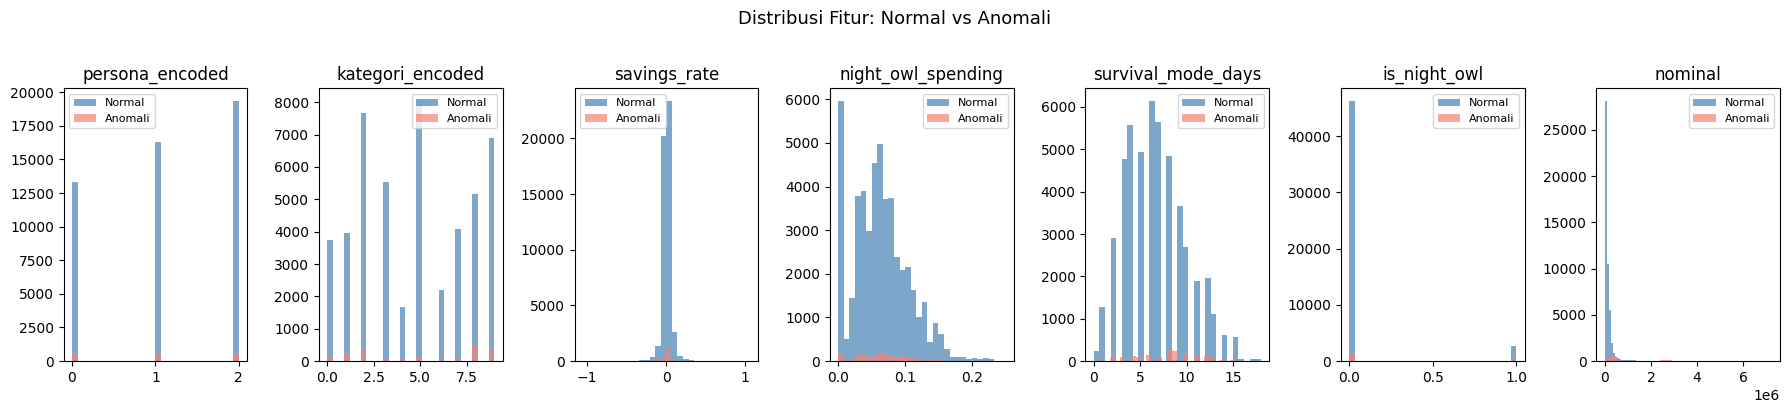

In [62]:
figure, axes = plt.subplots(1, len(FEATURE_COLUMNS), figsize=(18, 4))

for index, column_name in enumerate(FEATURE_COLUMNS):
    normal_values  = dataframe_debit.loc[dataframe_debit['label_anomali'] == 0, column_name]
    anomaly_values = dataframe_debit.loc[dataframe_debit['label_anomali'] == 1, column_name]

    axes[index].hist(normal_values,  bins=30, alpha=0.7, label='Normal',  color='steelblue')
    axes[index].hist(anomaly_values, bins=30, alpha=0.7, label='Anomali', color='salmon')
    axes[index].set_title(column_name)
    axes[index].legend(fontsize=8)

plt.suptitle('Distribusi Fitur: Normal vs Anomali', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Normalisasi

- **Fitur non-nominal** (`persona_encoded`, `kategori_encoded`, `savings_rate`, `night_owl_spending`, `survival_mode_days`, `is_night_owl`): StandardScaler **per segmen demografi**.
- **`nominal`**: StandardScaler **per segmen + kategori_detail** — karena baseline pengeluaran tiap kombinasi berbeda signifikan.

Semua scaler di-fit **hanya pada transaksi normal** (label baru) agar distribusi anomali tidak mempengaruhi skala.

In [63]:
NON_NOMINAL_FEATURES       = [col for col in FEATURE_COLUMNS if col != 'nominal']
SCALED_NON_NOMINAL_COLUMNS = [f'{col}_scaled' for col in NON_NOMINAL_FEATURES]
SCALED_FEATURE_COLUMNS     = [f'{col}_scaled' for col in FEATURE_COLUMNS]

scaler_per_segment         = {}
scaler_nominal_per_seg_kat = {}

dataframe_debit['segmen_demografi'] = dataframe_debit['segmen_demografi'].fillna('Unknown')

# Per-segmen untuk fitur non-nominal
for segment_name in dataframe_debit['segmen_demografi'].unique():
    segment_mask        = dataframe_debit['segmen_demografi'] == segment_name
    normal_segment_mask = segment_mask & (dataframe_debit['label_anomali'] == 0)
    fit_mask            = normal_segment_mask if normal_segment_mask.sum() >= 2 else segment_mask

    scaler = StandardScaler()
    scaler.fit(dataframe_debit.loc[fit_mask, NON_NOMINAL_FEATURES])
    scaler_per_segment[segment_name] = scaler

    dataframe_debit.loc[segment_mask, SCALED_NON_NOMINAL_COLUMNS] = scaler.transform(
        dataframe_debit.loc[segment_mask, NON_NOMINAL_FEATURES]
    )

# Per-(segmen + kategori_detail) untuk nominal
seg_kat_combos = (
    dataframe_debit[['segmen_demografi', 'kategori_detail']]
    .drop_duplicates()
    .values
)

for segment_name, kategori_name in seg_kat_combos:
    combo_mask        = (
        (dataframe_debit['segmen_demografi'] == segment_name) &
        (dataframe_debit['kategori_detail']  == kategori_name)
    )
    normal_combo_mask = combo_mask & (dataframe_debit['label_anomali'] == 0)
    fit_mask          = normal_combo_mask if normal_combo_mask.sum() >= 2 else combo_mask

    scaler = StandardScaler()
    scaler.fit(dataframe_debit.loc[fit_mask, ['nominal']])
    scaler_nominal_per_seg_kat[(segment_name, kategori_name)] = scaler

    dataframe_debit.loc[combo_mask, 'nominal_scaled'] = (
        scaler.transform(dataframe_debit.loc[combo_mask, ['nominal']]).ravel()
    )

print('Normalisasi selesai.')
print(f'Segmen diproses          : {list(scaler_per_segment.keys())}')
print(f'Kombinasi seg+kat nominal: {len(scaler_nominal_per_seg_kat)} (3 segmen × 10 kategori)')
print()
dataframe_debit[SCALED_FEATURE_COLUMNS].describe().round(3)

Normalisasi selesai.
Segmen diproses          : ['Mahasiswa', 'First Jobber', 'Profesional']
Kombinasi seg+kat nominal: 30 (3 segmen × 10 kategori)



,persona_encoded_scaled,kategori_encoded_scaled,savings_rate_scaled,night_owl_spending_scaled,survival_mode_days_scaled,is_night_owl_scaled,nominal_scaled
count,50730.000,50730.000,50730.000,50730.000,50730.000,50730.000,50730.000
mean,-0.006,0.005,-0.011,0.004,0.008,0.030,0.303
std,1.001,1.005,1.004,1.003,1.001,1.056,2.665
min,-1.482,-1.599,-11.704,-2.045,-2.435,-0.250,-2.135
25%,-1.338,-0.912,-0.226,-0.709,-0.752,-0.250,-0.626
50%,-0.117,0.113,-0.092,-0.063,-0.060,-0.244,-0.228
75%,0.997,1.139,0.032,0.601,0.734,-0.242,0.543
max,1.144,1.490,11.580,3.917,4.090,4.140,51.049


## 9. Visualisasi Fitur Setelah Normalisasi

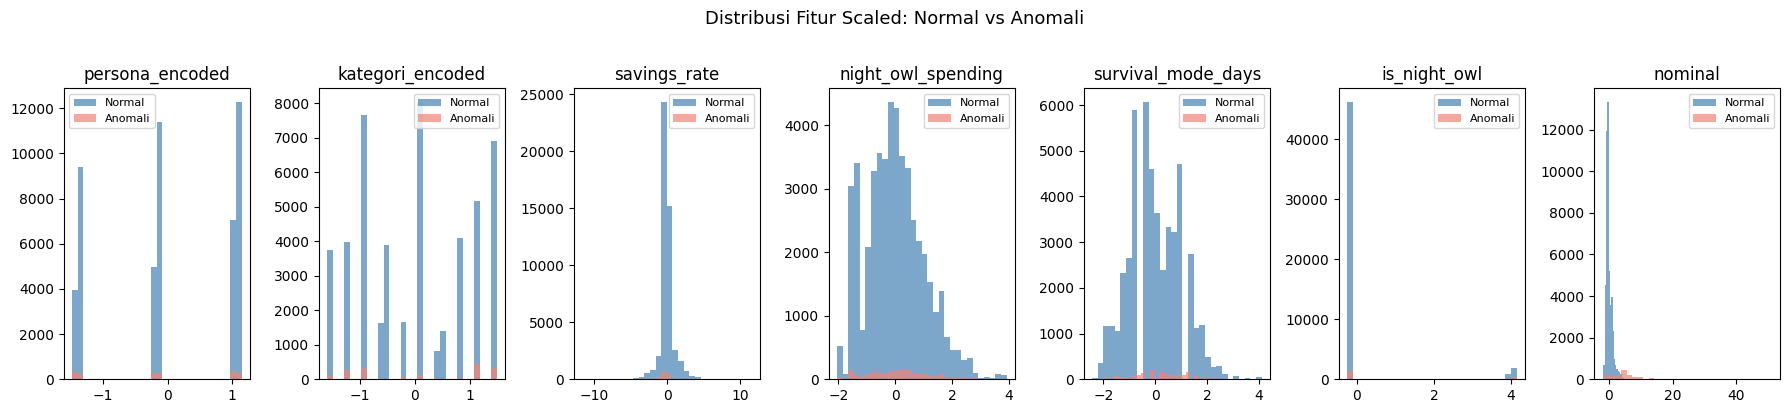

In [64]:
figure, axes = plt.subplots(1, len(SCALED_FEATURE_COLUMNS), figsize=(18, 4))

for index, column_name in enumerate(SCALED_FEATURE_COLUMNS):
    normal_values  = dataframe_debit.loc[dataframe_debit['label_anomali'] == 0, column_name]
    anomaly_values = dataframe_debit.loc[dataframe_debit['label_anomali'] == 1, column_name]

    axes[index].hist(normal_values,  bins=30, alpha=0.7, label='Normal',  color='steelblue')
    axes[index].hist(anomaly_values, bins=30, alpha=0.7, label='Anomali', color='salmon')
    axes[index].set_title(column_name.replace('_scaled', ''))
    axes[index].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Scaled: Normal vs Anomali', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

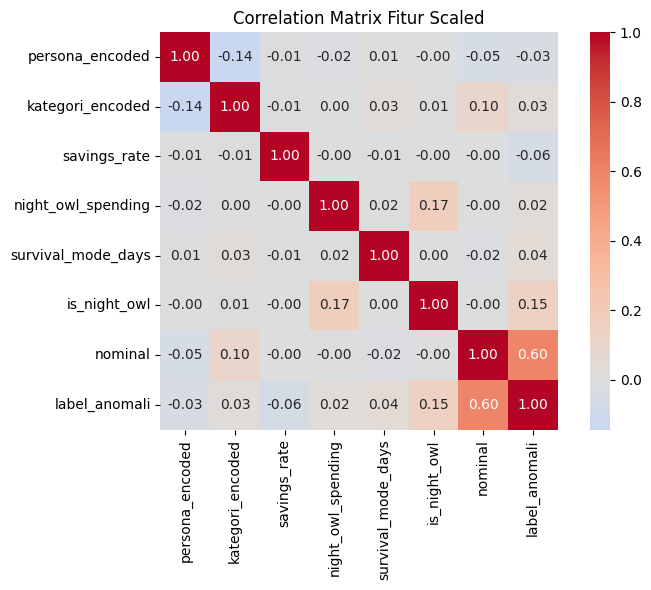

In [65]:
correlation_matrix = dataframe_debit[SCALED_FEATURE_COLUMNS + ['label_anomali']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    xticklabels=[col.replace('_scaled', '') for col in correlation_matrix.columns],
    yticklabels=[col.replace('_scaled', '') for col in correlation_matrix.index],
)
plt.title('Correlation Matrix Fitur Scaled')
plt.tight_layout()
plt.show()

## 10. Susun Dataset Training & Simpan

In [66]:
OUTPUT_COLUMNS = (
    ['id_transaksi', 'id_user', 'bulan', 'segmen_demografi', 'kategori_detail']
    + FEATURE_COLUMNS
    + SCALED_FEATURE_COLUMNS
    + ['label_anomali']
)

dataframe_training = dataframe_debit[OUTPUT_COLUMNS].copy()

print(f'Shape dataset training : {dataframe_training.shape}')
print(f'Kolom                  : {list(dataframe_training.columns)}')
print()
print('Distribusi label:')
print(dataframe_training['label_anomali'].value_counts())
print(f'  Rasio anomali        : {dataframe_training["label_anomali"].mean():.2%}')
print()
dataframe_training.head(5)

Shape dataset training : (50730, 20)
Kolom                  : ['id_transaksi', 'id_user', 'bulan', 'segmen_demografi', 'kategori_detail', 'persona_encoded', 'kategori_encoded', 'savings_rate', 'night_owl_spending', 'survival_mode_days', 'is_night_owl', 'nominal', 'persona_encoded_scaled', 'kategori_encoded_scaled', 'savings_rate_scaled', 'night_owl_spending_scaled', 'survival_mode_days_scaled', 'is_night_owl_scaled', 'nominal_scaled', 'label_anomali']

Distribusi label:
label_anomali
0    48957
1     1773
Name: count, dtype: int64
  Rasio anomali        : 3.49%



,id_transaksi,id_user,bulan,segmen_demografi,kategori_detail,persona_encoded,kategori_encoded,savings_rate,night_owl_spending,survival_mode_days,is_night_owl,nominal,persona_encoded_scaled,kategori_encoded_scaled,savings_rate_scaled,night_owl_spending_scaled,survival_mode_days_scaled,is_night_owl_scaled,nominal_scaled,label_anomali
0,TRX-10140,USR-001,1,Mahasiswa,Hiburan & Langganan,2,3,0.001871,0.111111,4,0,186000.00,1.144319,-0.569232,-0.058902,1.021899,-0.431078,-0.250459,0.791191,0
1,TRX-10141,USR-001,1,Mahasiswa,Kesehatan & Perawatan Diri,2,5,0.001871,0.111111,4,0,150000.00,1.144319,0.117255,-0.058902,1.021899,-0.431078,-0.250459,-0.079818,0
2,TRX-11790,USR-001,1,Mahasiswa,Hiburan & Langganan,2,3,0.001871,0.111111,4,0,112017.17,1.144319,-0.569232,-0.058902,1.021899,-0.431078,-0.250459,-0.412413,0
3,TRX-11792,USR-001,1,Mahasiswa,Belanja Online & Fashion,2,0,0.001871,0.111111,4,0,595635.11,1.144319,-1.598962,-0.058902,1.021899,-0.431078,-0.250459,2.442012,0
4,TRX-11794,USR-001,1,Mahasiswa,NLP Classified Transfer,2,6,0.001871,0.111111,4,0,73294.82,1.144319,0.460498,-0.058902,1.021899,-0.431078,-0.250459,0.006820,0


In [67]:
MODEL_DIRECTORY    = '/Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/model'
OUTPUT_CSV_PATH    = f'{DATA_DIRECTORY}/training_data_autoencoder.csv'
OUTPUT_SCALER_PATH = f'{MODEL_DIRECTORY}/scaler_per_segment.pkl'

os.makedirs(MODEL_DIRECTORY, exist_ok=True)
dataframe_training.to_csv(OUTPUT_CSV_PATH, index=False)

joblib.dump({
    'scaler_per_segment'         : scaler_per_segment,
    'scaler_nominal_per_seg_kat' : scaler_nominal_per_seg_kat,
    'feature_columns'            : FEATURE_COLUMNS,
    'scaled_feature_columns'     : SCALED_FEATURE_COLUMNS,
    'persona_encoding_map'       : PERSONA_ENCODING_MAP,
    'kategori_encoding_map'      : KATEGORI_ENCODING_MAP,
}, OUTPUT_SCALER_PATH)

print(f'Dataset training  → {OUTPUT_CSV_PATH}')
print(f'Scaler & metadata → {OUTPUT_SCALER_PATH}')

Dataset training  → /Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/data/training_data_autoencoder.csv
Scaler & metadata → /Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/model/scaler_per_segment.pkl


## 11. Ringkasan Dataset

In [68]:
print('=' * 50)
print('RINGKASAN DATASET TRAINING')
print('=' * 50)
print(f'Total baris              : {len(dataframe_training):,}')
print(f'User unik                : {dataframe_training["id_user"].nunique()}')
print(f'Transaksi normal         : {(dataframe_training["label_anomali"] == 0).sum():,}')
print(f'Transaksi anomali        : {(dataframe_training["label_anomali"] == 1).sum():,}')
print()
print('Segmen demografi:')
for segment_name, segment_count in dataframe_training['segmen_demografi'].value_counts().items():
    print(f'  {segment_name:<15} : {segment_count:,} transaksi')
print()
print('Fitur yang siap dipakai untuk training:')
for feature_name in SCALED_FEATURE_COLUMNS:
    print(f'  {feature_name}')
print('=' * 50)

RINGKASAN DATASET TRAINING
Total baris              : 50,730
User unik                : 500
Transaksi normal         : 48,957
Transaksi anomali        : 1,773

Segmen demografi:
  First Jobber    : 19,420 transaksi
  Profesional     : 16,940 transaksi
  Mahasiswa       : 14,370 transaksi

Fitur yang siap dipakai untuk training:
  persona_encoded_scaled
  kategori_encoded_scaled
  savings_rate_scaled
  night_owl_spending_scaled
  survival_mode_days_scaled
  is_night_owl_scaled
  nominal_scaled
